# Objectif 2 - Modelisation post-voyage

Ce notebook traite le second objectif du projet : expliquer la satisfaction client apres la realisation du sejour.

Contrairement au modele pre-voyage, cette experience peut utiliser des variables observees pendant ou apres le sejour :

- `imprevus` ;
- `reorganisation_necessaire` ;
- `respect_budget` ;
- informations extraites de `retour_client`.

Ce modele ne doit pas etre presente comme un modele de prediction avant depart. Il sert a comprendre les facteurs de satisfaction ou d'insatisfaction et a alimenter une boucle d'amelioration continue.

## 1. Configuration

On limite volontairement le nombre de threads afin de garder une execution compatible avec une machine disposant de peu de RAM.

In [ ]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import RandomizedSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 30)

## 2. Chargement du dataset

Le dataset utilise reste le fichier brut fourni pour le projet. Les traitements sont reappliques dans ce notebook afin de rendre l'experience reproductible.

In [2]:
DATA_PATH = Path("..") / "data" / "Examen_travel_planning_dataset.csv"

if not DATA_PATH.exists():
    DATA_PATH = Path("data") / "Examen_travel_planning_dataset.csv"

df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head())

(1500, 15)


,trip_id,client_type,budget_total,destination,saison,duree_jours,type_hebergement,prix_vol,meteo_prevue,activite_principale,satisfaction_client,imprevus,reorganisation_necessaire,respect_budget,retour_client
0,1,solo,5548.90,Dubaï,automne,3,hôtel,1320.77,ensoleillé,plage,3.0,annulation,1,0,Séjour mitigé.
1,2,business,3288.27,Rome,printemps,12,hôtel,1524.09,variable,randonnée,4.0,aucun,0,1,Excellent séjour.
2,3,senior,13347.18,Bali,printemps,16,villa,881.94,ensoleillé,plage,5.0,météo,1,1,Excellent séjour.
3,4,couple,7049.42,Sydney,automne,17,appartement,844.39,nuageux,randonnée,3.0,météo,1,1,Séjour mitigé.
4,5,solo,7612.92,Paris,hiver,7,hôtel,1081.24,pluie,gastronomie,2.0,retard_vol,1,1,Séjour mitigé.


## 3. Objectif metier et cible

Objectif post-voyage : expliquer `satisfaction_client` apres le sejour.

La cible reste le score de satisfaction client sur 5 classes :

```text
1 = tres insatisfait
5 = tres satisfait
```

Dans ce cadre, les variables post-voyage sont autorisees car le modele est retrospectif.

In [3]:
target_column = "satisfaction_client"
post_voyage_variables = ["imprevus", "reorganisation_necessaire", "respect_budget"]
text_variable = "retour_client"

print("Cible :", target_column)
print("Variables post-voyage utilisees :", post_voyage_variables)
print("Variable texte exploitee sous forme d'indicateurs :", text_variable)

Cible : satisfaction_client
Variables post-voyage utilisees : ['imprevus', 'reorganisation_necessaire', 'respect_budget']
Variable texte exploitee sous forme d'indicateurs : retour_client


## 4. Nettoyage minimal

Les traitements restent volontairement simples et coherents avec les notebooks precedents :

- normalisation des textes en minuscules ;
- conversion des variables numeriques ;
- suppression des lignes sans cible exploitable ;
- suppression des incoherences budgetaires fortes ;
- imputation simple des valeurs manquantes.

Le but est de comparer proprement l'apport des variables post-voyage, pas de changer toute la preparation des donnees.

In [4]:
df_model = df_raw.copy()

for column in df_model.select_dtypes(include=["object", "string"]).columns:
    df_model[column] = df_model[column].astype(str).str.strip().str.lower()

numeric_source_columns = [
    "budget_total",
    "duree_jours",
    "prix_vol",
    "satisfaction_client",
    "reorganisation_necessaire",
    "respect_budget",
]

for column in numeric_source_columns:
    df_model[column] = pd.to_numeric(df_model[column], errors="coerce")

df_model = df_model[df_model[target_column].between(1, 5)].copy()
df_model[target_column] = df_model[target_column].astype(int)

df_model = df_model[
    df_model["prix_vol"].isna()
    | df_model["budget_total"].isna()
    | (df_model["prix_vol"] <= df_model["budget_total"])
].copy()

for column in ["budget_total", "duree_jours", "prix_vol"]:
    df_model[column] = df_model[column].fillna(df_model[column].median())

categorical_columns_to_fill = [
    "client_type",
    "destination",
    "saison",
    "type_hebergement",
    "meteo_prevue",
    "activite_principale",
]

for column in categorical_columns_to_fill:
    df_model[column] = df_model[column].fillna("inconnu").replace({"nan": "inconnu"})

df_model["imprevus"] = df_model["imprevus"].fillna("aucun").replace({"nan": "aucun"})
df_model["retour_client"] = df_model["retour_client"].fillna("").replace({"nan": ""})

for column in ["reorganisation_necessaire", "respect_budget"]:
    mode_value = df_model[column].mode(dropna=True).iloc[0]
    df_model[column] = df_model[column].fillna(mode_value).astype(int)

print(df_model.shape)
display(df_model[target_column].value_counts().sort_index().rename("nombre"))

(1418, 15)


satisfaction_client
1    252
2    411
3    341
4    248
5    166
Name: nombre, dtype: int64

## 5. Feature engineering post-voyage

On conserve les variables pre-voyage deja creees dans les autres notebooks, puis on ajoute des variables specifiques au post-voyage.

La variable `retour_client` n'est pas injectee brute dans le modele. Elle est transformee en indicateurs simples :

- `sentiment_retour` : score lexical positif/negatif ;
- `retour_client_vide` : presence ou absence d'un commentaire.

In [5]:
safe_duree = df_model["duree_jours"].replace(0, np.nan)
safe_budget = df_model["budget_total"].replace(0, np.nan)

df_model["budget_par_jour"] = df_model["budget_total"] / safe_duree
df_model["part_vol_budget"] = df_model["prix_vol"] / safe_budget
df_model["budget_hors_vol"] = df_model["budget_total"] - df_model["prix_vol"]
df_model["sejour_long"] = (df_model["duree_jours"] >= 14).astype(int)
df_model["meteo_risque"] = df_model["meteo_prevue"].isin(["pluie", "variable"]).astype(int)
df_model["randonnee_meteo_risque"] = (
    df_model["activite_principale"].isin(["randonn?e", "randonnee"])
    & df_model["meteo_prevue"].isin(["pluie", "variable"])
).astype(int)
df_model["saison_haute"] = df_model["saison"].isin(["?t?", "ete", "hiver"]).astype(int)
df_model["client_business"] = (df_model["client_type"] == "business").astype(int)
df_model["hebergement_luxe"] = df_model["type_hebergement"].isin(["resort", "villa"]).astype(int)

# Variables operationnelles post-voyage autorisees.
# Elles decrivent ce qui s'est passe pendant le sejour, sans utiliser l'avis client textuel.
df_model["imprevu_present"] = (df_model["imprevus"] != "aucun").astype(int)
df_model["imprevu_transport"] = df_model["imprevus"].isin(["retard_vol", "annulation", "bagages"]).astype(int)
df_model["imprevu_meteo"] = df_model["imprevus"].isin(["m?t?o", "meteo"]).astype(int)
df_model["budget_non_respecte"] = (df_model["respect_budget"] == 0).astype(int)
df_model["gravite_imprevu"] = df_model["imprevus"].map({
    "aucun": 0,
    "m?t?o": 1,
    "meteo": 1,
    "bagages": 1,
    "retard_vol": 2,
    "annulation": 3,
}).fillna(1).astype(int)

df_model["annulation_et_reorganisation"] = (
    (df_model["imprevus"] == "annulation")
    & (df_model["reorganisation_necessaire"] == 1)
).astype(int)
df_model["retard_et_budget_non_respecte"] = (
    (df_model["imprevus"] == "retard_vol")
    & (df_model["budget_non_respecte"] == 1)
).astype(int)
df_model["imprevu_transport_et_sejour_court"] = (
    (df_model["imprevu_transport"] == 1)
    & (df_model["duree_jours"] <= 5)
).astype(int)
df_model["budget_tendu_et_hebergement_luxe"] = (
    (df_model["part_vol_budget"] >= 0.5)
    & (df_model["hebergement_luxe"] == 1)
).astype(int)

df_model["budget_tendu"] = (df_model["part_vol_budget"] >= 0.5).astype(int)

# Variables derivees de retour_client : conservees uniquement pour analyse descriptive / NLP separe,
# mais exclues du modele principal sans fuite.
positive_words = ["excellent", "parfait", "super", "agr?able", "agreable", "satisfait", "magnifique", "recommande"]
negative_words = ["mitig?", "mitige", "d?cevant", "decevant", "mauvais", "probl?me", "probleme", "retard", "annulation"]

def score_sentiment(text):
    text = str(text).lower()
    positive_score = sum(word in text for word in positive_words)
    negative_score = sum(word in text for word in negative_words)
    return positive_score - negative_score

df_model["sentiment_retour"] = df_model["retour_client"].apply(score_sentiment)
df_model["retour_client_vide"] = (df_model["retour_client"].str.len() == 0).astype(int)

for column in ["budget_par_jour", "part_vol_budget", "budget_hors_vol"]:
    df_model[column] = df_model[column].replace([np.inf, -np.inf], np.nan)

features_post_voyage_explicatives = [
    "imprevus",
    "reorganisation_necessaire",
    "respect_budget",
    "imprevu_present",
    "imprevu_transport",
    "imprevu_meteo",
    "budget_non_respecte",
    "budget_tendu",
    "gravite_imprevu",
    "annulation_et_reorganisation",
    "retard_et_budget_non_respecte",
    "imprevu_transport_et_sejour_court",
    "budget_tendu_et_hebergement_luxe",
]

features_texte_non_retenues = ["retour_client", "sentiment_retour", "retour_client_vide"]

display(df_model[features_post_voyage_explicatives + [target_column]].head())
print("Variables texte exclues du modele principal :")
print(features_texte_non_retenues)

,imprevus,reorganisation_necessaire,respect_budget,imprevu_present,imprevu_transport,imprevu_meteo,budget_non_respecte,budget_tendu,gravite_imprevu,annulation_et_reorganisation,retard_et_budget_non_respecte,imprevu_transport_et_sejour_court,budget_tendu_et_hebergement_luxe,satisfaction_client
0,annulation,1,0,1,1,0,1,0,3,1,0,1,0,3
1,aucun,0,1,0,0,0,0,0,0,0,0,0,0,4
2,météo,1,1,1,0,0,0,0,1,0,0,0,0,5
3,météo,1,1,1,0,0,0,0,1,0,0,0,0,3
4,retard_vol,1,1,1,1,0,0,0,2,0,0,0,0,2


Variables texte exclues du modele principal :
['retour_client', 'sentiment_retour', 'retour_client_vide']


## 6. Variables d'entree du modele

Dans ce notebook post-voyage, on inclut volontairement les variables observees apres ou pendant le sejour.

On exclut uniquement :

- `trip_id`, car c'est un identifiant technique ;
- `satisfaction_client`, car c'est la cible ;
- `retour_client`, car le texte brut est remplace par des indicateurs simples.

In [6]:
leakage_columns = [
    "retour_client",
    "sentiment_retour",
    "retour_client_vide",
    "tokens",
    "mots_utiles",
    "mots_propres",
    "mots_cles",
    "entites",
    "score_avis",
    "sentiment_avis_label",
    "sentiment_avis",
    "nb_tokens",
    "nb_mots_utiles",
    "nb_mots_cles",
    "nb_entites",
]

excluded_columns = ["trip_id", target_column, *[column for column in leakage_columns if column in df_model.columns]]
feature_columns = [column for column in df_model.columns if column not in excluded_columns]

X = df_model[feature_columns].copy()
y = df_model[target_column].copy()

numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

resume_variables = pd.DataFrame({
    "famille": ["numeriques", "categorielles", "total", "exclues"],
    "nombre": [len(numeric_features), len(categorical_features), X.shape[1], len(excluded_columns)],
    "colonnes": [numeric_features, categorical_features, feature_columns, excluded_columns],
})

display(resume_variables)
print("Variables post-voyage operationnelles presentes dans X :")
print([column for column in features_post_voyage_explicatives if column in X.columns])
print("Variables exclues pour eviter la fuite de donnees :")
print([column for column in leakage_columns if column in df_model.columns])

,famille,nombre,colonnes
0,numeriques,24,"[budget_total, duree_jours, prix_vol, reorgani..."
1,categorielles,7,"[client_type, destination, saison, type_heberg..."
2,total,31,"[client_type, budget_total, destination, saiso..."
3,exclues,5,"[trip_id, satisfaction_client, retour_client, ..."


Variables post-voyage operationnelles presentes dans X :
['imprevus', 'reorganisation_necessaire', 'respect_budget', 'imprevu_present', 'imprevu_transport', 'imprevu_meteo', 'budget_non_respecte', 'budget_tendu', 'gravite_imprevu', 'annulation_et_reorganisation', 'retard_et_budget_non_respecte', 'imprevu_transport_et_sejour_court', 'budget_tendu_et_hebergement_luxe']
Variables exclues pour eviter la fuite de donnees :
['retour_client', 'sentiment_retour', 'retour_client_vide']


## 7. Separation train/test et pipeline

La separation train/test reste stratifiee pour conserver la distribution des classes de satisfaction.

L'imputation, la standardisation et l'encodage sont integres dans un pipeline afin d'eviter toute fuite entre train et test.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Train :", X_train.shape)
print("Test  :", X_test.shape)

Train : (1134, 31)
Test  : (284, 31)


### Analyse de correlation des variables numeriques

La satisfaction client est une note ordinale. On utilise donc la correlation de Spearman, plus adaptee qu'une correlation lineaire classique.

Le calcul est realise uniquement sur le jeu d'entrainement pour eviter que le jeu de test influence l'analyse.

,variable,correlation_spearman_satisfaction,niveau_relation
0,imprevu_present,-0.2285,faible
1,gravite_imprevu,-0.2152,faible
2,imprevu_transport,-0.1500,faible
3,reorganisation_necessaire,-0.1489,faible
4,respect_budget,0.1420,faible
5,budget_non_respecte,-0.1420,faible
6,retard_et_budget_non_respecte,-0.1010,faible
7,budget_tendu,-0.0721,tres faible
8,imprevu_transport_et_sejour_court,-0.0619,tres faible
9,annulation_et_reorganisation,-0.0581,tres faible


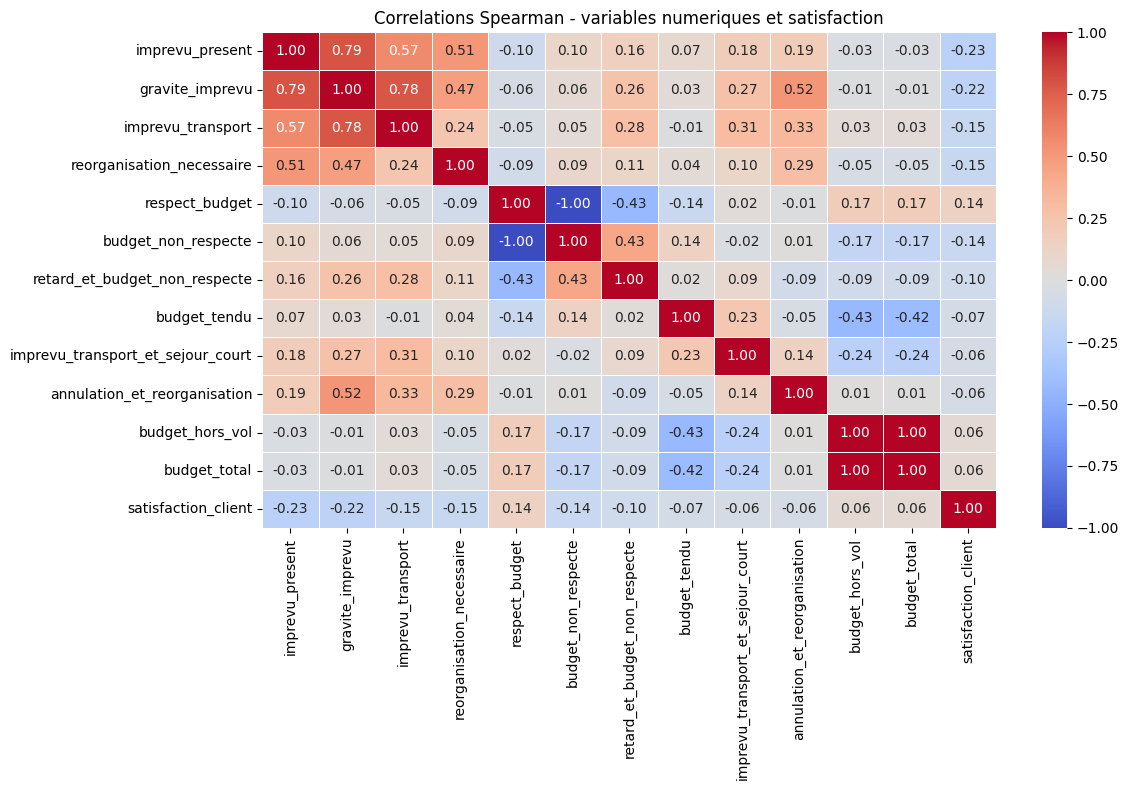

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

if len(numeric_features) == 0:
    print("Aucune variable numerique disponible pour la correlation.")
else:
    train_correlation_df = X_train[numeric_features].copy()
    train_correlation_df[target_column] = y_train.values

    spearman_target = (
        train_correlation_df
        .corr(method="spearman")[target_column]
        .drop(target_column)
        .sort_values(key=lambda values: values.abs(), ascending=False)
    )

    correlation_table = (
        spearman_target
        .reset_index()
        .rename(columns={
            "index": "variable",
            target_column: "correlation_spearman_satisfaction",
        })
    )

    def interpreter_correlation(value):
        valeur_absolue = abs(value)
        if valeur_absolue >= 0.50:
            return "forte"
        if valeur_absolue >= 0.30:
            return "moderee"
        if valeur_absolue >= 0.10:
            return "faible"
        return "tres faible"

    correlation_table["niveau_relation"] = correlation_table[
        "correlation_spearman_satisfaction"
    ].apply(interpreter_correlation)

    display(correlation_table.round(4))

    top_correlation_features = correlation_table.head(12)["variable"].tolist()
    correlation_matrix = train_correlation_df[
        top_correlation_features + [target_column]
    ].corr(method="spearman")

    plt.figure(figsize=(12, 8))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5,
    )
    plt.title("Correlations Spearman - variables numeriques et satisfaction")
    plt.tight_layout()
    plt.show()

## 8. Modelisation post-voyage

On compare un modele naif avec trois modeles simples et legers :

- `DummyClassifier` comme baseline ;
- `LogisticRegression` pour une reference interpretable ;
- `RandomForestClassifier` pour capter des relations non lineaires ;
- `ExtraTreesClassifier` comme variante d'arbres aleatoires.

La metrique principale reste `macro_f1`, car elle tient compte de toutes les classes.

In [9]:
models = {
    "Dummy_majority": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    trained_pipelines[model_name] = pipeline
    results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
    })

results_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(results_df.round(4))

,modele,accuracy,balanced_accuracy,macro_f1
3,ExtraTrees,0.2641,0.2808,0.2573
2,RandomForest,0.2711,0.2687,0.2536
1,LogisticRegression,0.2465,0.2526,0.2390
0,Dummy_majority,0.2887,0.2000,0.0896


## 9. Optimisation legere sans fuite

Pour ameliorer le modele post-voyage sans utiliser `retour_client`, on optimise legerement `RandomForest`, qui est le meilleur modele de base dans la version sans fuite.

Cette optimisation reste volontairement limitee pour respecter la contrainte de RAM :

- `n_jobs=1` ;
- `cv=3` ;
- nombre d'essais limite ;
- scoring principal : `f1_macro`.

L'objectif est d'ameliorer le modele sans introduire de variables qui donnent directement la reponse.

In [10]:
random_forest_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    )),
])

param_distributions = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [None, 6, 8, 10, 12],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", None],
}

search_random_forest = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=1,
    verbose=1,
)

search_random_forest.fit(X_train, y_train)

y_pred_optimized = search_random_forest.predict(X_test)
optimized_results = pd.DataFrame([{
    "modele": "RandomForest_optimise_sans_fuite",
    "accuracy": accuracy_score(y_test, y_pred_optimized),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_optimized),
    "macro_f1": f1_score(y_test, y_pred_optimized, average="macro"),
}])

print("Meilleurs hyperparametres :")
print(search_random_forest.best_params_)
print("Meilleur score CV f1_macro :", round(search_random_forest.best_score_, 4))
display(optimized_results.round(4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Meilleurs hyperparametres :
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 6}
Meilleur score CV f1_macro : 0.2536


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_optimise_sans_fuite,0.3204,0.33,0.3075


### Interpretation de l'optimisation sans fuite

Si le score progresse, l'amelioration vient de deux sources acceptables :

- meilleures interactions operationnelles post-voyage ;
- hyperparametres plus adaptes.

Si le score progresse peu, cela confirme que le signal operationnel disponible reste limite, meme apres optimisation.

Dans les deux cas, cette experience est plus propre que l'utilisation de `retour_client`, car elle evite un proxy direct de la satisfaction.

## 10. Cible post-voyage en 3 classes

La prediction exacte de `satisfaction_client` sur 5 classes reste difficile, car les notes proches peuvent etre ambigues.

On teste donc une cible plus robuste en 3 niveaux :

```text
0 = insatisfait : notes 1 et 2
1 = neutre : note 3
2 = satisfait : notes 4 et 5
```

Cette formulation reste sans fuite de donnees, car elle utilise les memes variables explicatives que le modele principal, sans `retour_client`.

In [11]:
def satisfaction_to_3_classes(value):
    if value <= 2:
        return 0
    if value == 3:
        return 1
    return 2


y_three_classes = y.apply(satisfaction_to_3_classes)

print("Distribution de la cible 3 classes :")
display(
    y_three_classes.value_counts()
    .sort_index()
    .rename_axis("classe_satisfaction")
    .reset_index(name="nombre")
    .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
)

X_train_three, X_test_three, y_train_three, y_test_three = train_test_split(
    X,
    y_three_classes,
    test_size=0.2,
    random_state=42,
    stratify=y_three_classes,
)

three_class_models = {
    "Dummy_majority_3_classes": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression_3_classes": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_3_classes": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_3_classes": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
}

three_class_results = []

for model_name, model in three_class_models.items():
    pipeline_three = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])
    pipeline_three.fit(X_train_three, y_train_three)
    y_pred_three = pipeline_three.predict(X_test_three)
    three_class_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_three, y_pred_three),
        "balanced_accuracy": balanced_accuracy_score(y_test_three, y_pred_three),
        "macro_f1": f1_score(y_test_three, y_pred_three, average="macro"),
    })

three_class_results_df = pd.DataFrame(three_class_results).sort_values("macro_f1", ascending=False)
display(three_class_results_df.round(4))

Distribution de la cible 3 classes :


,classe_satisfaction,nombre,pourcentage
0,0,663,46.76
1,1,341,24.05
2,2,414,29.20


,modele,accuracy,balanced_accuracy,macro_f1
2,RandomForest_3_classes,0.4577,0.4032,0.3938
3,ExtraTrees_3_classes,0.4190,0.3759,0.3730
1,LogisticRegression_3_classes,0.3627,0.3619,0.3537
0,Dummy_majority_3_classes,0.4683,0.3333,0.2126


### Test SMOTE sur la cible 3 classes

SMOTE est testé uniquement sur le jeu d'entraînement, à l'intérieur d'un pipeline `imblearn`, pour éviter toute fuite de données vers le jeu de test.

L'objectif est de vérifier si le rééquilibrage artificiel des classes améliore le `macro_f1`, indicateur prioritaire lorsque les classes de satisfaction sont déséquilibrées.

In [12]:
print("Distribution du train avant SMOTE :")
display(
    y_train_three.value_counts()
    .sort_index()
    .rename_axis("classe_satisfaction")
    .reset_index(name="nombre")
    .assign(pourcentage=lambda data: (data["nombre"] / data["nombre"].sum() * 100).round(2))
)

smote_models_three = {
    "LogisticRegression_3_classes_SMOTE": LogisticRegression(
        max_iter=500,
        class_weight=None,
    ),
    "RandomForest_3_classes_SMOTE": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight=None,
        n_jobs=1,
    ),
    "ExtraTrees_3_classes_SMOTE": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight=None,
        n_jobs=1,
    ),
}

smote_results_three = []

for model_name, model in smote_models_three.items():
    smote_pipeline_three = ImbPipeline(steps=[
        ("preprocess", preprocess),
        ("smote", SMOTE(random_state=42, k_neighbors=5)),
        ("model", model),
    ])

    smote_pipeline_three.fit(X_train_three, y_train_three)
    y_pred_three_smote = smote_pipeline_three.predict(X_test_three)

    smote_results_three.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_three, y_pred_three_smote),
        "balanced_accuracy": balanced_accuracy_score(y_test_three, y_pred_three_smote),
        "macro_f1": f1_score(y_test_three, y_pred_three_smote, average="macro"),
    })

smote_results_three_df = pd.DataFrame(smote_results_three)

comparison_three_with_smote = (
    pd.concat([three_class_results_df, smote_results_three_df], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_three_with_smote.round(4))

Distribution du train avant SMOTE :


,classe_satisfaction,nombre,pourcentage
0,0,530,46.74
1,1,273,24.07
2,2,331,29.19


,modele,accuracy,balanced_accuracy,macro_f1
0,RandomForest_3_classes,0.4577,0.4032,0.3938
1,ExtraTrees_3_classes_SMOTE,0.4437,0.3863,0.3766
2,ExtraTrees_3_classes,0.4190,0.3759,0.3730
3,RandomForest_3_classes_SMOTE,0.4472,0.3870,0.3700
4,LogisticRegression_3_classes_SMOTE,0.3697,0.3669,0.3593
5,LogisticRegression_3_classes,0.3627,0.3619,0.3537
6,Dummy_majority_3_classes,0.4683,0.3333,0.2126


### Lecture du test SMOTE

SMOTE est retenu uniquement si le `macro_f1` augmente de manière claire par rapport au meilleur modèle 3 classes sans SMOTE.

Si l'amélioration est faible ou négative, cela signifie que le problème vient davantage du manque de signal explicatif que du déséquilibre des classes.

### Optimisation ciblée de RandomForest

Cette expérience teste une configuration plus poussée de `RandomForest` sur la cible 3 classes.

Les paramètres testés sont :

- `n_estimators = 500`
- `max_depth = 10`
- `min_samples_leaf = 5`
- `min_samples_split = 10`
- `random_state = 42`

Le `class_weight="balanced"` est conservé pour rester cohérent avec l'objectif `macro_f1`, sensible aux classes minoritaires.

In [ ]:
random_forest_optimise_three = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    )),
])

random_forest_optimise_three.fit(X_train_three, y_train_three)
y_pred_rf_optim_three = random_forest_optimise_three.predict(X_test_three)

rf_optim_results_three_df = pd.DataFrame([{
    "modele": "RandomForest_3_classes_optimise_500",
    "accuracy": accuracy_score(y_test_three, y_pred_rf_optim_three),
    "balanced_accuracy": balanced_accuracy_score(y_test_three, y_pred_rf_optim_three),
    "macro_f1": f1_score(y_test_three, y_pred_rf_optim_three, average="macro"),
}])

base_results_for_rf_optim = globals().get(
    "comparison_three_with_smote",
    three_class_results_df,
)

comparison_three_with_rf_optim = (
    pd.concat([base_results_for_rf_optim, rf_optim_results_three_df], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_three_with_rf_optim.round(4))

### Lecture de l'optimisation RandomForest

Cette configuration est retenue uniquement si elle améliore clairement le `macro_f1` par rapport au `RandomForest_3_classes` initial.

Si le gain est faible ou négatif, cela indique que l'amélioration ne vient pas d'un simple réglage d'hyperparamètres.

### Test XGBoost optimisé manuellement

Cette expérience teste `XGBoost` sur la cible 3 classes avec une configuration manuelle plus régularisée.

Paramètres testés :

- `n_estimators = 500`
- `max_depth = 4`
- `learning_rate = 0.03`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `random_state = 42`

Le modèle utilise le même prétraitement que les autres modèles scikit-learn : imputation, standardisation des numériques et encodage One-Hot des catégorielles.

In [ ]:
xgboost_pipeline_three = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=1,
    )),
])

xgboost_pipeline_three.fit(X_train_three, y_train_three)
y_pred_xgboost_three = xgboost_pipeline_three.predict(X_test_three)

xgboost_results_three_df = pd.DataFrame([{
    "modele": "XGBoost_3_classes_optimise",
    "accuracy": accuracy_score(y_test_three, y_pred_xgboost_three),
    "balanced_accuracy": balanced_accuracy_score(y_test_three, y_pred_xgboost_three),
    "macro_f1": f1_score(y_test_three, y_pred_xgboost_three, average="macro"),
}])

base_results_for_xgboost = globals().get(
    "comparison_three_with_rf_optim",
    globals().get("comparison_three_with_smote", three_class_results_df),
)

comparison_three_with_xgboost = (
    pd.concat([base_results_for_xgboost, xgboost_results_three_df], ignore_index=True)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(comparison_three_with_xgboost.round(4))

### Lecture du test XGBoost

XGBoost est retenu uniquement s'il améliore clairement le `macro_f1` par rapport au meilleur `RandomForest_3_classes`.

Si le score reste inférieur ou proche, cela confirme que l'amélioration ne vient pas seulement du choix d'un algorithme plus avancé.

### Diagnostic du modele 3 classes sans fuite

Cette cellule analyse les erreurs du meilleur modele conserve sans fuite de donnees. L'objectif n'est pas seulement d'obtenir un score, mais de comprendre quelles classes sont confondues.

In [14]:
best_three_class_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    )),
])

best_three_class_pipeline.fit(X_train_three, y_train_three)
y_pred_three_best = best_three_class_pipeline.predict(X_test_three)

labels_three = [0, 1, 2]
labels_three_readable = [
    "insatisfait_1_2",
    "neutre_3",
    "satisfait_4_5",
]

confusion_three = pd.DataFrame(
    confusion_matrix(y_test_three, y_pred_three_best, labels=labels_three),
    index=[f"reel_{label}" for label in labels_three_readable],
    columns=[f"predit_{label}" for label in labels_three_readable],
)

print("Matrice de confusion :")
display(confusion_three)

report_three = pd.DataFrame(
    classification_report(
        y_test_three,
        y_pred_three_best,
        labels=labels_three,
        target_names=labels_three_readable,
        output_dict=True,
        zero_division=0,
    )
).transpose()

print("Rapport de classification :")
display(report_three.round(4))

Matrice de confusion :


,predit_insatisfait_1_2,predit_neutre_3,predit_satisfait_4_5
reel_insatisfait_1_2,84,19,30
reel_neutre_3,39,9,20
reel_satisfait_4_5,34,12,37


Rapport de classification :


,precision,recall,f1-score,support
insatisfait_1_2,0.5350,0.6316,0.5793,133.0000
neutre_3,0.2250,0.1324,0.1667,68.0000
satisfait_4_5,0.4253,0.4458,0.4353,83.0000
accuracy,0.4577,0.4577,0.4577,0.4577
macro avg,0.3951,0.4032,0.3938,284.0000
weighted avg,0.4287,0.4577,0.4384,284.0000


### Importance des variables sans fuite

Cette analyse permet d'identifier les variables les plus utilisees par le modele. Elle aide a verifier si le modele s'appuie sur des variables metier pertinentes ou sur du bruit.

In [15]:
feature_names_three = best_three_class_pipeline.named_steps["preprocess"].get_feature_names_out()
importances_three = best_three_class_pipeline.named_steps["model"].feature_importances_

importance_three_df = (
    pd.DataFrame({
        "feature": feature_names_three,
        "importance": importances_three,
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(importance_three_df.round(4))

,feature,importance
5,num__budget_par_jour,0.0829
6,num__part_vol_budget,0.0751
0,num__budget_total,0.0725
7,num__budget_hors_vol,0.0724
2,num__prix_vol,0.0702
1,num__duree_jours,0.0549
18,num__gravite_imprevu,0.0298
14,num__imprevu_present,0.0274
17,num__budget_non_respecte,0.0185
4,num__respect_budget,0.0177


### Test de selection automatique des variables

Ce test verifie si une partie des variables ajoute du bruit. La selection est apprise uniquement sur le jeu d'entrainement via le pipeline, puis appliquee au test.

In [16]:
selected_pipeline_three = Pipeline(steps=[
    ("preprocess", preprocess),
    ("selector", SelectFromModel(
        ExtraTreesClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=1,
        ),
        threshold="median",
    )),
    ("model", RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    )),
])

selected_pipeline_three.fit(X_train_three, y_train_three)
y_pred_three_selected = selected_pipeline_three.predict(X_test_three)

selected_feature_count = int(selected_pipeline_three.named_steps["selector"].get_support().sum())

selected_results_three = pd.DataFrame([{
    "modele": "RandomForest_3_classes_selection",
    "features_conservees": selected_feature_count,
    "accuracy": accuracy_score(y_test_three, y_pred_three_selected),
    "balanced_accuracy": balanced_accuracy_score(y_test_three, y_pred_three_selected),
    "macro_f1": f1_score(y_test_three, y_pred_three_selected, average="macro"),
}])

print(f"Nombre de variables conservees apres encodage : {selected_feature_count}")
display(selected_results_three.round(4))

Nombre de variables conservees apres encodage : 31


,modele,features_conservees,accuracy,balanced_accuracy,macro_f1
0,RandomForest_3_classes_selection,31,0.3662,0.3248,0.3149


### Validation croisee du modele 3 classes

La validation croisee teste la stabilite du modele sur plusieurs decoupages. Si les ecarts sont forts, le score obtenu sur un seul train/test split doit etre interprete avec prudence.

In [17]:
cv_pipeline_three = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    )),
])

cv_results_three = cross_validate(
    cv_pipeline_three,
    X,
    y_three_classes,
    cv=3,
    scoring={
        "macro_f1": "f1_macro",
        "balanced_accuracy": "balanced_accuracy",
    },
    n_jobs=1,
)

cv_summary_three = pd.DataFrame({
    "metrique": ["macro_f1", "balanced_accuracy"],
    "moyenne": [
        cv_results_three["test_macro_f1"].mean(),
        cv_results_three["test_balanced_accuracy"].mean(),
    ],
    "ecart_type": [
        cv_results_three["test_macro_f1"].std(),
        cv_results_three["test_balanced_accuracy"].std(),
    ],
})

display(cv_summary_three.round(4))

,metrique,moyenne,ecart_type
0,macro_f1,0.3731,0.0291
1,balanced_accuracy,0.3907,0.0192


### Lecture des tests complementaires

Ces tests permettent de choisir les prochaines actions de maniere rationnelle :

- si la matrice de confusion montre une forte confusion entre classes voisines, la cible 3 classes reste plus coherente que la note exacte ;
- si peu de variables portent l'importance, il faut simplifier le modele ou enrichir les donnees ;
- si la selection de variables ameliore le score, certaines variables actuelles ajoutent du bruit ;
- si la validation croisee est instable, le dataset manque probablement de signal robuste.

### Interpretation de la cible 3 classes

Si cette experience ameliore le `macro_f1`, cela signifie que le probleme initial etait trop fin pour les donnees disponibles.

Une cible en 3 classes est souvent plus exploitable metier : elle distingue les sejours insatisfaisants, neutres et satisfaisants sans chercher a predire exactement chaque note.

## 11. Interpretation attendue

Cette experience doit normalement obtenir de meilleurs resultats que le modele pre-voyage, car elle utilise des informations plus proches de la satisfaction finale.

L'interpretation metier attendue est la suivante :

- les evenements reels du sejour expliquent davantage la satisfaction que les caracteristiques initiales du voyage ;
- les variables post-voyage confirment ou infirment les causes d'insatisfaction ;
- le modele est utile pour l'analyse qualite et l'amelioration continue ;
- il ne doit pas etre utilise pour faire une prediction avant depart.

In [ ]:
best_model_name = results_df.iloc[0]["modele"]
best_score = results_df.iloc[0]["macro_f1"]

print(f"Meilleur modele : {best_model_name}")
print(f"Macro F1 : {best_score:.4f}")

comparison_note = pd.DataFrame({
    "objectif": ["pre-voyage", "post-voyage"],
    "variables_post_voyage": ["exclues", "incluses"],
    "usage": ["prediction avant depart", "analyse retrospective"],
})

display(comparison_note)

Meilleur modele : ExtraTrees
Macro F1 : 0.2573


,objectif,variables_post_voyage,usage
0,pre-voyage,exclues,prediction avant depart
1,post-voyage,incluses,analyse retrospective


: 

## 12. Experience NLP sur `retour_client`

Cette section ajoute une analyse NLP du commentaire client avec :

- `spaCy` pour les traitements linguistiques classiques : tokenisation, stop words, lemmatisation, POS tagging et entites nommees ;
- un pipeline `transformers` pour extraire un score de sentiment.

Cette experience reste strictement post-voyage : `retour_client` est connu apres le sejour. Les variables NLP ne doivent donc pas etre utilisees dans le modele pre-voyage.

Cette section est conservee comme analyse exploratoire. Elle n'est pas retenue comme modele principal sans fuite, car le commentaire client est tres proche de la satisfaction finale.

Installation des dependances NLP :

```powershell
pip install -r requirements-nlp.txt
python -m spacy download fr_core_news_sm
```

`fr_core_news_sm` est choisi volontairement pour limiter la consommation RAM. Le modele `fr_core_news_lg` charge de gros vecteurs et peut provoquer un `MemoryError` sur une machine avec 4 Go de RAM.

Remarque : le modele `nlptown/bert-base-multilingual-uncased-sentiment` est un modele BERT multilingue specialise pour le sentiment. Il n'est pas CamemBERT au sens strict, mais il permet une analyse de sentiment en francais.

In [ ]:
import spacy
from transformers import pipeline

SPACY_MODEL_NAME = "fr_core_news_sm"
SENTIMENT_MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"

try:
    nlp = spacy.load(SPACY_MODEL_NAME)
except OSError as error:
    nlp = None
    print(f"Modele spaCy indisponible : {SPACY_MODEL_NAME}")
    print("Installe-le avec : python -m spacy download fr_core_news_sm")
    print(f"Erreur : {error}")

try:
    analyseur = pipeline(
        "sentiment-analysis",
        model=SENTIMENT_MODEL_NAME,
        device=-1,
    )
except Exception as error:
    analyseur = None
    print(f"Pipeline de sentiment indisponible : {SENTIMENT_MODEL_NAME}")
    print("Installe les dependances avec : pip install -r requirements-nlp.txt")
    print(f"Erreur : {error}")

c:\Users\khadi\Downloads\Examen_IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Etape 1 - Tokenisation : decouper le texte en mots
def etape1(texte):
    if nlp is None:
        return []
    doc = nlp(str(texte))
    return [token.text for token in doc]


# Etape 2 - Stop words : enlever les mots peu informatifs
def etape2(texte):
    if nlp is None:
        return []
    doc = nlp(str(texte))
    return [
        token.text
        for token in doc
        if not token.is_stop
        and not token.is_punct
    ]


# Etape 3 - Lemmatisation : ramener les mots a leur forme de base
def etape3(texte):
    if nlp is None:
        return ""
    doc = nlp(str(texte))
    return " ".join([token.lemma_ for token in doc])


# Etape 4 - POS tagging : extraire adjectifs et noms
def etape4(texte):
    if nlp is None:
        return []
    doc = nlp(str(texte))
    return [token.text for token in doc if token.pos_ in ["ADJ", "NOUN"]]


# Etape 5 - NER : detecter lieux, organisations, dates, etc.
def etape5(texte):
    if nlp is None:
        return []
    doc = nlp(str(texte))
    return [ent.text for ent in doc.ents]


# Etape 6 - Sentiment avec pipeline Transformers
def etape6(texte):
    if str(texte).strip() == "" or analyseur is None:
        return 0.0, "neutre"
    try:
        resultat = analyseur(str(texte), truncation=True)[0]
        label = resultat["label"]
        score = float(resultat["score"])

        if label in ["4 stars", "5 stars"]:
            return round(score, 2), "positif"
        if label in ["1 star", "2 stars"]:
            return round(-score, 2), "negatif"
        return 0.0, "neutre"
    except Exception:
        return 0.0, "neutre"

In [ ]:
# Appliquer les etapes NLP sur la colonne retour_client
# Les colonnes liste/texte servent a l'analyse, mais ne seront pas injectees directement dans X.
df_model["tokens"] = df_model["retour_client"].apply(etape1)
df_model["mots_utiles"] = df_model["retour_client"].apply(etape2)
df_model["mots_propres"] = df_model["retour_client"].apply(etape3)
df_model["mots_cles"] = df_model["retour_client"].apply(etape4)
df_model["entites"] = df_model["retour_client"].apply(etape5)

# Eviter d'appeler le modele de sentiment deux fois par ligne
resultats_sentiment = df_model["retour_client"].apply(etape6)
df_model["score_avis"] = resultats_sentiment.apply(lambda resultat: resultat[0])
df_model["sentiment_avis_label"] = resultats_sentiment.apply(lambda resultat: resultat[1])

# Encoder sentiment_avis en chiffres
mapping_sentiment = {"negatif": 0, "neutre": 1, "positif": 2}
df_model["sentiment_avis"] = (
    df_model["sentiment_avis_label"]
    .map(mapping_sentiment)
    .fillna(1)
    .astype(int)
)

# Variables numeriques derivees des sorties NLP
df_model["nb_tokens"] = df_model["tokens"].apply(len)
df_model["nb_mots_utiles"] = df_model["mots_utiles"].apply(len)
df_model["nb_mots_cles"] = df_model["mots_cles"].apply(len)
df_model["nb_entites"] = df_model["entites"].apply(len)

nlp_features = [
    "score_avis",
    "sentiment_avis",
    "nb_tokens",
    "nb_mots_utiles",
    "nb_mots_cles",
    "nb_entites",
]

display(
    df_model[
        ["retour_client", "score_avis", "sentiment_avis_label", "sentiment_avis"]
    ].drop_duplicates().head(20)
)
print("NLP termine")

### Modelisation avec variables NLP

On ajoute uniquement des variables numeriques issues du NLP dans `X` :

- `score_avis` ;
- `sentiment_avis` ;
- `nb_tokens` ;
- `nb_mots_utiles` ;
- `nb_mots_cles` ;
- `nb_entites`.

Les colonnes `tokens`, `mots_utiles`, `mots_propres`, `mots_cles` et `entites` sont conservees pour l'analyse qualitative, mais elles ne sont pas envoyees directement au modele.

In [ ]:
X_nlp = X.copy().reset_index(drop=True)
nlp_features_aligned = df_model[nlp_features].reset_index(drop=True)

for column in nlp_features:
    X_nlp[column] = nlp_features_aligned[column]

numeric_features_nlp = X_nlp.select_dtypes(include="number").columns.tolist()
categorical_features_nlp = X_nlp.select_dtypes(include=["object", "string", "category"]).columns.tolist()

X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    X_nlp,
    y.reset_index(drop=True),
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocess_nlp = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features_nlp),
    ("cat", categorical_transformer, categorical_features_nlp),
])

nlp_models = {
    "LogisticRegression_NLP": LogisticRegression(max_iter=500, class_weight="balanced"),
    "RandomForest_NLP": RandomForestClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
    "ExtraTrees_NLP": ExtraTreesClassifier(
        n_estimators=120,
        max_depth=8,
        random_state=42,
        class_weight="balanced",
        n_jobs=1,
    ),
}

nlp_results = []

for model_name, model in nlp_models.items():
    pipeline_nlp = Pipeline(steps=[
        ("preprocess", preprocess_nlp),
        ("model", model),
    ])
    pipeline_nlp.fit(X_train_nlp, y_train_nlp)
    y_pred_nlp = pipeline_nlp.predict(X_test_nlp)
    nlp_results.append({
        "modele": model_name,
        "accuracy": accuracy_score(y_test_nlp, y_pred_nlp),
        "balanced_accuracy": balanced_accuracy_score(y_test_nlp, y_pred_nlp),
        "macro_f1": f1_score(y_test_nlp, y_pred_nlp, average="macro"),
    })

nlp_results_df = pd.DataFrame(nlp_results).sort_values("macro_f1", ascending=False)
display(nlp_results_df.round(4))

### Interpretation de l'experience NLP

Si les scores augmentent, cela confirme que `retour_client` contient un signal fort pour expliquer la satisfaction.

Cette amelioration doit etre interpretee comme un resultat post-voyage. Elle ne rend pas le modele utilisable avant le depart, car le commentaire client est disponible uniquement apres le sejour.

L'interet metier du NLP est donc l'analyse qualite : comprendre les irritants, detecter les themes recurrents et alimenter l'amelioration continue des offres.

## 13. Conclusion

Le modele post-voyage constitue une experience separee du modele principal pre-voyage.

Il permet de repondre a un autre besoin metier : comprendre les facteurs qui influencent la satisfaction apres le sejour. Cette approche est utile pour :

- identifier les causes d'insatisfaction ;
- suivre la qualite operationnelle ;
- ameliorer les offres futures ;
- enrichir progressivement les donnees disponibles avant depart.

La distinction entre les deux objectifs est essentielle :

- le modele pre-voyage est conforme au cas d'usage de planification, mais dispose de peu de signal ;
- le modele post-voyage contient davantage de signal, mais il est retrospectif et non deployable pour une prediction avant depart.